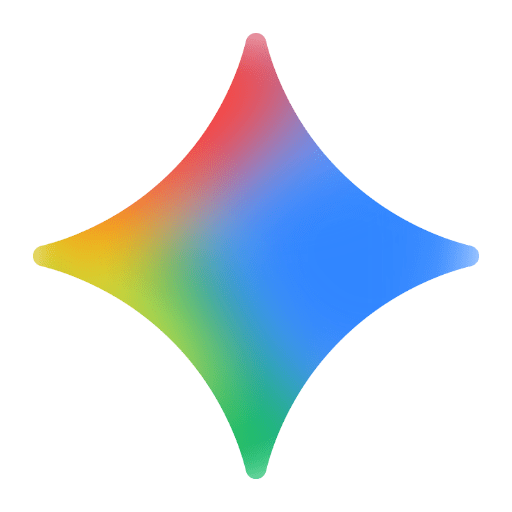

# Chapter 14: Financial and Legal Domain Agents

**Book:** *30 Agents Every AI Engineer Must Build*
**Author:** Imran Ahmad

Powered by **Google Gemini Flash 2.5**
**Publisher:** Packt Publishing, 2026

---

> *"The measure of intelligence is the ability to change."* — Albert Einstein

## Chapter Overview

Building agents for finance and law is a different game entirely. The general-purpose architectures from earlier chapters could afford trial and error — these cannot. A single compliance failure in a regulated domain does not just produce a bad answer. It can trigger fines, sanctions, or criminal liability. Every recommendation must be traced back to its data sources. Every decision must withstand regulatory audit. Every interaction must be logged with enough detail to reconstruct the reasoning months or years later.

This notebook implements two **production-grade agent architectures** for regulated domains, corresponding to Chapter 14 (pp. 391–420) of the book:

### Part 1 — Financial Advisory Agent (Section 14.1, pp. 392–408)

A **supervised multi-agent system** (Figure 14.1) that coordinates specialist agents through a LangGraph `StateGraph`:

- **Supervisor Agent** — Policy-aware orchestrator that routes queries to specialists and enforces compliance gates
- **Market Data Agent** — Wraps yfinance and Finnhub for real-time stock data (prices, P/E, market cap)
- **Financial Analysis Agent** — Computes portfolio metrics using Finnhub API endpoints
- **News Agent** — Retrieves qualitative market context via Tavily search
- **Risk Scoring** — Composite 0–10 scale combining annualized volatility (40%), maximum drawdown (35%), and Value at Risk (25%)
- **Compliance-by-Architecture** — Structurally impossible for non-compliant recommendations to reach the client

### Part 2 — Legal Intelligence Agent (Section 14.2, pp. 408–419)

A **RAG-powered legal research system** with hybrid retrieval and citation verification:

- **Legal Knowledge Base** — Hybrid search combining dense vector retrieval with authority-weighted ranking
- **Authority Ranking** — `final_score = 0.5 × similarity + 0.3 × authority + 0.2 × recency`
- **3-Stage Precedent Pipeline** — Issue Extraction → Multi-Dimensional Retrieval → Synthesis and Verification
- **5-Stage Contract Analysis** — Document Ingestion → Clause Extraction → Risk Flagging → Compliance Validation → Summary Generation
- **Citation Verification Gate** — Cross-references every citation against the knowledge base to detect hallucinated case law

### Key Insight: Compliance Is Architecture, Not a Feature

In regulated industries, compliance is not a feature added after the agent works correctly. It is an **architectural constraint** that shapes every design decision from the outset. Both agents demonstrate this principle — the financial agent's validation gate makes it structurally impossible for non-compliant recommendations to pass through, and the legal agent's citation verification gate ensures only verified precedent enters the final brief.

---

**Chapter Reference:** pp. 391–420
**Figures:** 14.1 (Multi-Agent Financial Architecture), 14.2 (Legal Precedent Pipeline), 14.3 (Contract Analysis Framework)
**Table:** 14.1 (Performance Impact of AI-Powered Personalization, p. 403)

> ⚠️ **Disclaimer:** Both agents are designed as educational demonstrations. Financial outputs are illustrative and must not be treated as investment advice. Legal outputs are illustrative and must not be treated as legal opinions.

## Cell 0: Setup and Configuration

**Ref:** Technical Requirements (p.392)

This cell loads environment variables, detects API key availability per service, and configures the notebook to run in either **Live Mode** (with real APIs) or **Simulation Mode** (with chapter-faithful mock data).

In [1]:
import os
os.environ["LLM_PROVIDER"] = "google"

# Cell 0: Setup and Configuration
# Ref: Technical Requirements (p.392)
# Author: Imran Ahmad

import os
import sys
import json
import operator
import warnings
from functools import partial
from typing import Annotated, Sequence, TypedDict, Literal, List

import numpy as np
import pandas as pd

from dotenv import load_dotenv
load_dotenv()

from mock_llm import (
    ColorLogger,
    ServiceConfig,
    graceful_fallback,
    MockChatOpenAI,
    MockStructuredChain,
    MockEmbeddingModel,
    MockVectorStore,
)

from mock_data import (
    MOCK_STOCK_DATA,
    MOCK_FINNHUB_QUOTES,
    MOCK_FINNHUB_FINANCIALS,
    generate_mock_price_history,
    MOCK_TAVILY_NEWS,
    MOCK_CLIENT_PROFILES,
    MOCK_LEGAL_CASES,
    MOCK_CONTRACT,
    MOCK_INTER_AGENT_MESSAGE,
)

warnings.filterwarnings("ignore", category=DeprecationWarning)

config = ServiceConfig()
logger = ColorLogger("Chapter14")

# Conditional LLM selection — Ref: Technical Requirements (p.392)
if config.is_live("GOOGLE_API_KEY"):
    try:
        from langchain_google_genai import ChatGoogleGenerativeAI
        llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
        logger.success("Using LIVE Gemini LLM (gemini-2.5-flash)")
    except Exception as e:
        logger.error(f"ChatGoogleGenerativeAI init failed: {e}. Falling back to MockChatOpenAI.")
        llm = MockChatOpenAI(model="gemini-2.5-flash", temperature=0)
else:
    llm = MockChatOpenAI(model="gemini-2.5-flash", temperature=0)
    logger.info("Using SIMULATED LLM (MockChatOpenAI)")

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.tools import tool
from pydantic import BaseModel
from langgraph.prebuilt import create_react_agent
from langgraph.graph import END, START, StateGraph

logger.success("Setup complete — all imports loaded")


══════════════════════════════════════════════════════
  CHAPTER 14 — SERVICE STATUS DASHBOARD
  Book: 30 Agents Every AI Engineer Must Build
  Author: Imran Ahmad
══════════════════════════════════════════════════════
  OpenAI (LLM)                        ● LIVE
  Finnhub (Financial Data)            ○ SIMULATED
  Tavily (News Search)                ○ SIMULATED
══════════════════════════════════════════════════════

[17:10:20] [Chapter14] INFO [Simulation Mode] MockChatOpenAI initialized (model=gemini-2.5-flash)
[17:10:20] [Chapter14] INFO Using SIMULATED LLM (MockChatOpenAI)
[17:10:20] [Chapter14] SUCCESS Setup complete — all imports loaded


## Cell 1: Supervisor Architecture

**Ref:** Section 14.1, Figure 14.1 (pp. 393–395)

The Financial Advisory Agent uses a **supervised multi-agent architecture** (Figure 14.1). A central Supervisor Agent serves as both entry point and policy-aware orchestrator, deciding which specialist to invoke, in what order, and with what state recorded at each step.

**Specialist agents:** Market Data Agent, Financial Analysis Agent, News Agent

**Figure 14.1 — Multi-agent architecture for the Financial Advisory Agent:**

```
                  ┌─────────────────┐
                  │ Analysis Agent  │
                  │(Financial       │
                  │ Metrics)        │
                  └───────┬─────────┘
                          │
                          ▼
┌─────────────────┐ ┌───────────┐ ┌─────────────────┐
│ Market Data     │←│Supervisor │→│   Risk Agent    │
│ Agent           │ │   Agent   │ │  (VaR /         │
│(yfinance /      │ │           │ │   Volatility)   │
│ Finnhub)        │ └─────┬─────┘ └─────────────────┘
└─────────────────┘       │
                    FINISH (Post-Audit)
                          │
                          ▼
                  ┌───────────────┐
                  │  Compliance   │
                  │  Validated    │
                  │Recommendation│
                  └───────────────┘
```

The state-graph routing mechanism is the key architectural safeguard — it turns the advisory process into a traceable sequence of states and transitions, making it possible to enforce tool permissions, require human checkpoints, and attach an audit trail to every recommendation.

In [2]:
# Cell 1: Supervisor Architecture
# Ref: Section 14.1, Figure 14.1 (p.393-395)
# Author: Imran Ahmad

class RouteResponse(BaseModel):
    next: Literal[
        "Market_Data_Agent",
        "Financial_Analysis_Agent",
        "News_Agent",
        "FINISH"
    ]

members = ["Market_Data_Agent", "Financial_Analysis_Agent", "News_Agent"]

system_prompt = (
    "You are a Financial Services Supervisor managing: "
    f"{', '.join(members)}. "
    "Route queries to the appropriate specialist. "
    "Use Market_Data_Agent for price and volume data. "
    "Use Financial_Analysis_Agent for financial computations. "
    "Use News_Agent for market news and sentiment. "
    "Select FINISH when the query is fully resolved."
)

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    MessagesPlaceholder(variable_name="messages"),
    ("system", "Choose the next agent from: {options}.")
]).partial(options=str(members + ["FINISH"]))

def supervisor_agent(state):
    """Route to the next specialist agent via structured output.
    Ref: Section 14.1, p.395"""
    chain = prompt | llm.with_structured_output(RouteResponse)
    return {"next": chain.invoke(state).next}

logger.success("Supervisor architecture initialized")
logger.info(f"Agent team: {members}")

[17:10:20] [Chapter14] SUCCESS Supervisor architecture initialized
[17:10:20] [Chapter14] INFO Agent team: ['Market_Data_Agent', 'Financial_Analysis_Agent', 'News_Agent']


## Cell 2: Market Data Agent

**Ref:** Section 14.1.1 (p.395–396)

The Market Data Agent wraps the `yfinance` library to retrieve real-time stock information. The `@graceful_fallback` decorator ensures that if the live API fails, the agent falls back to chapter-derived mock data.

In [3]:
# Cell 2: Market Data Agent
# Ref: Section 14.1.1, p.395-396
# Author: Imran Ahmad

@tool
def get_market_data(query: str) -> str:
    """Retrieve current market data for a given stock symbol.
    Ref: Section 14.1.1, p.395"""
    stock_symbol = query.strip().upper()

    if config.is_live("GOOGLE_API_KEY"):
        try:
            import yfinance as yf
            ticker = yf.Ticker(stock_symbol)
            info = ticker.info
            if not info or not info.get("currentPrice"):
                raise ValueError("Empty response")
            logger.success(f"[Market Data] LIVE data for {stock_symbol}")
        except Exception:
            info = MOCK_STOCK_DATA.get(stock_symbol, MOCK_STOCK_DATA["AAPL"])
            logger.info(f"[Market Data] Fallback to mock for {stock_symbol}")
    else:
        info = MOCK_STOCK_DATA.get(stock_symbol, MOCK_STOCK_DATA["AAPL"])
        logger.info(f"[Market Data] SIMULATED data for {stock_symbol}")

    return (
        f"Market Data for {stock_symbol}: "
        f"Price: ${info.get('currentPrice', 'N/A')}, "
        f"Market Cap: ${info.get('marketCap', 'N/A')}, "
        f"P/E Ratio: {info.get('trailingPE', 'N/A')}, "
        f"Day Range: ${info.get('dayLow', 'N/A')}-${info.get('dayHigh', 'N/A')}, "
        f"Volume: {info.get('volume', 'N/A')}"
    )

market_agent = create_react_agent(
    llm, tools=[get_market_data],
    state_modifier="You are the Market Data Agent. "
    "Retrieve real-time stock data for client queries."
)

# Demo
print(get_market_data.invoke("AAPL"))
logger.success("Market Data Agent initialized")

[17:10:20] [Chapter14] INFO [Simulation Mode] MockChatOpenAI initialized (model=gemini-2.5-flash)
[17:10:20] [Chapter14] INFO [Market Data] SIMULATED data for AAPL
Market Data for AAPL: Price: $178.72, Market Cap: $2800000000000, P/E Ratio: 28.5, Day Range: $176.5-$179.8, Volume: 52340000
[17:10:20] [Chapter14] SUCCESS Market Data Agent initialized


## Cell 3: Finnhub Integration — Portfolio Analysis

**Ref:** Section 14.1.1 (p.396)

For production deployments, the Finnhub API provides endpoints for basic financials, company metrics, real-time quotes, and company news.

In [4]:
# Cell 3: Finnhub Integration — Portfolio Analysis
# Ref: Section 14.1.1, p.396
# Author: Imran Ahmad

finnhub_client = None
if config.is_live("FINNHUB_API_KEY"):
    try:
        import finnhub
        finnhub_client = finnhub.Client(api_key=config.get_key("FINNHUB_API_KEY"))
        logger.success("[Finnhub] LIVE client initialized")
    except ImportError:
        logger.warning("[Finnhub] finnhub-python not installed — using mock")

@tool
def portfolio_analysis(query: str) -> str:
    """Fetch financial metrics using the Finnhub API.
    Ref: Section 14.1.1, p.396"""
    symbol = query.split()[-1].upper()

    if finnhub_client is not None:
        try:
            financials = finnhub_client.company_basic_financials(symbol, "all")
            metrics = financials.get("metric", {})
            logger.success(f"[Finnhub] LIVE financials for {symbol}")
        except Exception:
            financials = MOCK_FINNHUB_FINANCIALS.get(symbol, MOCK_FINNHUB_FINANCIALS["AAPL"])
            metrics = financials.get("metric", {})
            logger.info(f"[Finnhub] Fallback to mock for {symbol}")
    else:
        financials = MOCK_FINNHUB_FINANCIALS.get(symbol, MOCK_FINNHUB_FINANCIALS["AAPL"])
        metrics = financials.get("metric", {})
        logger.info(f"[Finnhub] SIMULATED financials for {symbol}")

    return (
        f"Portfolio Analysis for {symbol}: "
        f"P/E Ratio: {metrics.get('peRatio')}, "
        f"Revenue Growth: {metrics.get('revenueGrowth')}, "
        f"52W High: {metrics.get('52WeekHigh')}, "
        f"52W Low: {metrics.get('52WeekLow')}"
    )

analysis_agent = create_react_agent(
    llm, tools=[portfolio_analysis],
    state_modifier="You are the Financial Analysis Agent. "
    "Perform portfolio analysis and compute financial metrics."
)

print(portfolio_analysis.invoke("Analyze AAPL"))
logger.success("Financial Analysis Agent initialized")

[17:10:20] [Chapter14] INFO [Simulation Mode] MockChatOpenAI initialized (model=gemini-2.5-flash)
[17:10:20] [Chapter14] INFO [Finnhub] SIMULATED financials for AAPL
Portfolio Analysis for AAPL: P/E Ratio: 28.5, Revenue Growth: 7.8, 52W High: 199.62, 52W Low: 143.9
[17:10:20] [Chapter14] SUCCESS Financial Analysis Agent initialized


## Cell 4: Financial News Agent

**Ref:** Section 14.1.1 (p.397)

The Financial News Agent provides qualitative context using Tavily search-based retrieval. In Simulation Mode, it returns chapter-derived mock news results.

In [5]:
# Cell 4: Financial News Agent
# Ref: Section 14.1.1, p.397
# Author: Imran Ahmad

@tool
def search_financial_news(query: str) -> str:
    """Search for financial news using Tavily or mock data.
    Ref: Section 14.1.1, p.397"""
    if config.is_live("TAVILY_API_KEY"):
        try:
            from langchain_community.tools.tavily_search import TavilySearchResults
            tavily_tool = TavilySearchResults(max_results=5)
            results = tavily_tool.invoke(query)
            logger.success(f"[Tavily] LIVE search: {len(results)} results")
            return json.dumps(results, indent=2)
        except Exception as e:
            logger.warning(f"[Tavily] API error: {e} — using mock")

    logger.info("[Tavily] SIMULATED news search")
    return json.dumps(MOCK_TAVILY_NEWS, indent=2)

financial_news_agent = create_react_agent(
    llm, tools=[search_financial_news],
    state_modifier="You are the Financial News Agent. "
    "Retrieve and summarize the latest financial news "
    "relevant to the user's query."
)

# Demo
news_result = json.loads(search_financial_news.invoke("technology sector outlook"))
for item in news_result[:3]:
    print(f"  * {item['title']} (score: {item['score']})")
logger.success("Financial News Agent initialized")

[17:10:20] [Chapter14] INFO [Simulation Mode] MockChatOpenAI initialized (model=gemini-2.5-flash)
[17:10:20] [Chapter14] INFO [Tavily] SIMULATED news search
  * Federal Reserve Signals Cautious Approach to Rate Adjustments (score: 0.95)
  * Technology Sector Posts Strong Q4 Earnings (score: 0.91)
  * Global Trade Outlook Improves Amid Diplomatic Progress (score: 0.87)
[17:10:20] [Chapter14] SUCCESS Financial News Agent initialized


## Cell 5: StateGraph Assembly and Streaming Execution

**Ref:** Section 14.1 (p.397–399)

The supervisor orchestrates the specialist agents through a LangGraph `StateGraph`. This loop-until-complete pattern ensures complex multi-source queries are fully resolved before generating a response.

**Topology:** `START` → `supervisor` → conditional edge to specialist or `FINISH` → `END`. Each specialist returns to the supervisor for re-evaluation.

In [6]:
# Cell 5: StateGraph Assembly and Streaming Execution
# Ref: Section 14.1, p.397-399
# Author: Imran Ahmad

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    next: str

def agent_node(state, agent, name):
    """Execute a specialist agent and wrap its result for the state graph.
    Ref: Section 14.1, p.397"""
    result = agent.invoke(state)
    return {"messages": [HumanMessage(
        content=result["messages"][-1].content, name=name
    )]}

market_data_node = partial(agent_node, agent=market_agent, name="Market_Data_Agent")
analysis_node = partial(agent_node, agent=analysis_agent, name="Financial_Analysis_Agent")
news_node = partial(agent_node, agent=financial_news_agent, name="News_Agent")

workflow = StateGraph(AgentState)
workflow.add_node("Market_Data_Agent", market_data_node)
workflow.add_node("Financial_Analysis_Agent", analysis_node)
workflow.add_node("News_Agent", news_node)
workflow.add_node("supervisor", supervisor_agent)

for member in members:
    workflow.add_edge(member, "supervisor")

conditional_map = {m: m for m in members}
conditional_map["FINISH"] = END

workflow.add_conditional_edges(
    "supervisor", lambda x: x["next"], conditional_map
)
workflow.add_edge(START, "supervisor")

graph = workflow.compile()
logger.success("Financial Advisory StateGraph compiled")

# Execute streaming query — Ref: p.398-399
MockStructuredChain.reset()
logger.info("Executing: 'Analyze the portfolio for AAPL.'")
inputs = {"messages": [HumanMessage(content="Analyze the portfolio for AAPL.")]}

for output in graph.stream(inputs, stream_mode="values"):
    if "messages" in output:
        last_msg = output["messages"][-1]
        sender = getattr(last_msg, "name", "system")
        content = last_msg.content[:120] if last_msg.content else "(routing)"
        logger.info(f"[{sender}] {content}")

logger.success("StateGraph execution complete")

[17:10:20] [Chapter14] SUCCESS Financial Advisory StateGraph compiled
[17:10:20] [Chapter14] INFO Executing: 'Analyze the portfolio for AAPL.'
[17:10:20] [Chapter14] INFO [None] Analyze the portfolio for AAPL.
[17:10:20] [Chapter14] INFO [Supervisor] Routing to: Market_Data_Agent
[17:10:20] [Chapter14] INFO [None] Analyze the portfolio for AAPL.
[17:10:20] [Chapter14] INFO [Market Data] SIMULATED data for ANALYZE THE PORTFOLIO FOR AAPL.
[17:10:20] [Chapter14] INFO [Market_Data_Agent] Market Data for AAPL: Price: $178.72, Market Cap: $2800000000000, P/E Ratio: 28.5, Day Range: $176.50-$179.80, Volume: 5
[17:10:20] [Chapter14] INFO [Supervisor] Routing to: Financial_Analysis_Agent
[17:10:20] [Chapter14] INFO [Market_Data_Agent] Market Data for AAPL: Price: $178.72, Market Cap: $2800000000000, P/E Ratio: 28.5, Day Range: $176.50-$179.80, Volume: 5
[17:10:20] [Chapter14] INFO [Finnhub] SIMULATED financials for RANGE.
[17:10:20] [Chapter14] INFO [Financial_Analysis_Agent] Portfolio Analysis

## Cell 6: Risk Assessment Framework

**Ref:** Section 14.1.2 (pp. 399–404)

Three levels of risk evaluation:
1. **Basic volatility classification** — `|dp| > 5` → HIGH, `|dp| > 2` → MODERATE, else LOW
2. **Composite risk scoring** (`RiskScorer`) — 0.4 × volatility + 0.35 × drawdown + 0.25 × VaR (0–10 scale)
3. **Client tolerance adjustment** (`assess_risk`) — Maps market risk against conservative/moderate/aggressive tolerance

---

> 📌 **Info Box — Forty-five minutes, four hundred forty million dollars (p. 399)**
>
> On August 1, 2012, Knight Capital Group deployed a software update to its automated trading system. A configuration error reactivated dormant code that began executing millions of unintended trades across 154 stocks. In forty-five minutes, the firm accumulated $7 billion in erroneous positions and lost approximately $440 million — nearly its entire market capitalization. Knight was rescued through an emergency capital raise but never fully recovered, merging with Getco LLC the following year. The incident remains the canonical warning for automated financial systems: **speed without safeguards is not an advantage — it is a liability.** Every compliance gate, risk threshold, and human checkpoint described in this chapter exists to prevent precisely this kind of cascading failure.

---

> 📌 **Info Box — Key risk metrics (p. 400)**
>
> **Value at Risk (VaR)** estimates the maximum expected loss over a given time horizon at a specified confidence level (e.g., a 1-day 95% VaR of $10,000 means there is a 5% chance of losing more than $10,000 in a single day). **Conditional Value at Risk (CVaR)**, also called expected shortfall, measures the average loss in the worst-case scenarios beyond the VaR threshold, making it more sensitive to tail risk. **Annualized volatility** expresses the standard deviation of returns scaled to a one-year period, providing a comparable measure of price instability across assets. **Maximum drawdown** captures the largest peak-to-trough decline over a period, reflecting the worst loss an investor would have experienced had they bought at the peak and sold at the trough.

---

> 📌 **Info Box — Production data feeds (p. 398)**
>
> The yfinance library is suitable for prototyping and demonstration but does not provide the reliability guarantees required in regulated financial environments. Production systems should source market data from commercial providers such as Bloomberg, Refinitiv (LSEG Data & Analytics), or FactSet, which offer contractual SLA commitments, real-time feeds with sub-second latency, and data quality controls. When evaluating a provider, confirm coverage for all required asset classes, jurisdictional data permissions, and API rate limits that will hold under production load.

In [7]:
# Cell 6: Risk Assessment Framework
# Ref: Section 14.1.2, p.399-404
# Author: Imran Ahmad

# ── 1. Basic Volatility Classification ──
# Ref: p.400 — thresholds: abs(dp) > 5 → HIGH, > 2 → MODERATE, else LOW

def risk_assessment(query: str) -> str:
    """Evaluate investment risk using real-time volatility metrics.
    Ref: Section 14.1.2, p.400"""
    symbol = query.split()[-1].upper()

    if finnhub_client is not None:
        try:
            quote = finnhub_client.quote(symbol)
            logger.success(f"[Risk] LIVE quote for {symbol}")
        except Exception:
            quote = MOCK_FINNHUB_QUOTES.get(symbol, MOCK_FINNHUB_QUOTES["AAPL"])
            logger.info(f"[Risk] Fallback to mock quote for {symbol}")
    else:
        quote = MOCK_FINNHUB_QUOTES.get(symbol, MOCK_FINNHUB_QUOTES["AAPL"])
        logger.info(f"[Risk] SIMULATED quote for {symbol}")

    price_change = quote.get("dp", 0)

    if abs(price_change) > 5:
        risk_level = "High Risk"
    elif abs(price_change) > 2:
        risk_level = "Moderate Risk"
    else:
        risk_level = "Low Risk"

    return (
        f"Risk Assessment for {symbol}: "
        f"Price Change: {price_change}%, "
        f"Risk Level: {risk_level}"
    )

for sym in ["AAPL", "GOOGL", "MSFT"]:
    print(risk_assessment(f"Assess {sym}"))

print()

# ── 2. Composite Risk Scoring ──
# Ref: p.400-401 — weights: 0.4 vol + 0.35 dd + 0.25 var

class RiskScorer:
    """Multi-dimensional risk scoring for portfolio positions.
    Ref: Section 14.1.2, p.400-401"""

    def compute_risk_score(self, symbol: str,
                           lookback_days: int = 90) -> dict:
        """Compute composite risk score incorporating
        volatility, drawdown, and VaR metrics."""
        try:
            if config.is_live("GOOGLE_API_KEY"):
                import yfinance as yf
                ticker = yf.Ticker(symbol)
                hist = ticker.history(period=f"{lookback_days}d")
                if hist.empty:
                    raise ValueError("Empty history")
                logger.success(f"[RiskScorer] LIVE history for {symbol}")
            else:
                raise ValueError("Simulation mode")
        except Exception:
            mock_hist = generate_mock_price_history(symbol, days=lookback_days)
            hist = pd.DataFrame(mock_hist)
            logger.info(f"[RiskScorer] SIMULATED history for {symbol}")

        returns = hist["Close"].pct_change().dropna()

        # Ref: p.401
        volatility = returns.std() * np.sqrt(252)
        cumulative = (1 + returns).cumprod()
        rolling_max = cumulative.cummax()
        drawdown = (cumulative - rolling_max) / rolling_max
        max_drawdown = drawdown.min()
        var_95 = np.percentile(returns, 5)

        vol_score = min(volatility / 0.05, 10)
        dd_score = min(abs(max_drawdown) / 0.05, 10)
        var_score = min(abs(var_95) / 0.03, 10)

        composite = 0.4 * vol_score + 0.35 * dd_score + 0.25 * var_score

        return {
            "symbol": symbol,
            "annualized_volatility": round(float(volatility), 4),
            "max_drawdown": round(float(max_drawdown), 4),
            "var_95": round(float(var_95), 4),
            "composite_risk_score": round(float(composite), 2),
            "risk_category": self._categorize(float(composite)),
        }

    @staticmethod
    def _categorize(score: float) -> str:
        """Ref: p.401 — >= 7.0 HIGH, >= 4.0 MODERATE, else LOW"""
        if score >= 7.0:
            return "HIGH"
        elif score >= 4.0:
            return "MODERATE"
        return "LOW"

scorer = RiskScorer()
risk_result = scorer.compute_risk_score("AAPL")
print("--- Composite Risk Score ---")
for key, value in risk_result.items():
    print(f"  {key}: {value}")
print()

# ── 3. Client Tolerance Adjustment ──
# Ref: p.401-402

def assess_risk(stock_symbol: str, composite_score: float,
                client_risk_tolerance: str) -> dict:
    """Evaluate risk level adjusted for client tolerance.
    Ref: Section 14.1.2, p.401-402"""
    if composite_score >= 7.0:
        market_risk = "HIGH"
    elif composite_score >= 4.0:
        market_risk = "MODERATE"
    else:
        market_risk = "LOW"

    tolerance_map = {
        "conservative": {"HIGH": "UNACCEPTABLE", "MODERATE": "HIGH", "LOW": "MODERATE"},
        "moderate": {"HIGH": "HIGH", "MODERATE": "MODERATE", "LOW": "LOW"},
        "aggressive": {"HIGH": "MODERATE", "MODERATE": "LOW", "LOW": "LOW"},
    }

    adjusted_risk = tolerance_map.get(
        client_risk_tolerance, {}
    ).get(market_risk, market_risk)

    return {
        "symbol": stock_symbol,
        "market_risk": market_risk,
        "client_risk_tolerance": client_risk_tolerance,
        "adjusted_risk": adjusted_risk,
    }

print("--- Client Tolerance Adjustment ---")
for tolerance in ["conservative", "moderate", "aggressive"]:
    result = assess_risk("AAPL", risk_result["composite_risk_score"], tolerance)
    print(f"  {tolerance}: market={result['market_risk']} -> adjusted={result['adjusted_risk']}")

logger.success("Risk Assessment Framework complete")

[17:10:20] [Chapter14] INFO [Risk] SIMULATED quote for AAPL
Risk Assessment for AAPL: Price Change: 0.71%, Risk Level: Low Risk
[17:10:20] [Chapter14] INFO [Risk] SIMULATED quote for GOOGL
Risk Assessment for GOOGL: Price Change: 2.99%, Risk Level: Moderate Risk
[17:10:20] [Chapter14] INFO [Risk] SIMULATED quote for MSFT
Risk Assessment for MSFT: Price Change: -5.23%, Risk Level: High Risk

[17:10:20] [Chapter14] INFO [RiskScorer] SIMULATED history for AAPL
--- Composite Risk Score ---
  symbol: AAPL
  annualized_volatility: 0.209
  max_drawdown: -0.0899
  var_95: -0.0214
  composite_risk_score: 2.48
  risk_category: LOW

--- Client Tolerance Adjustment ---
  conservative: market=LOW -> adjusted=MODERATE
  moderate: market=LOW -> adjusted=LOW
  aggressive: market=LOW -> adjusted=LOW
[17:10:20] [Chapter14] SUCCESS Risk Assessment Framework complete


## Cell 7: Personalized Financial Planning and Compliance Gate

**Ref:** Section 14.1.3 (pp. 403–408)

The compliance gate implements **compliance-by-architecture**: it is structurally impossible for a non-compliant recommendation to reach the client. The `validate_compliance` node checks suitability and concentration limits (max 25%). If it fails, the `revise` node adjusts and loops back for re-validation.

**Table 14.1 (p. 403): Performance impact of AI-powered personalization in retail financial advisory**

| Metric | Before AI | After AI |
|:-------|:----------|:---------|
| Response time | 4-hour average | 30 seconds |
| Compliance accuracy | 95% | 99.99% |
| Client capacity | 100 per advisor | 1,000+ per advisor |
| Monthly revenue | $8,000 | $25,000 |

> 📌 **Industry Examples (p. 408):** JPMorgan Chase has invested in AI-driven summarization of market research, natural language understanding for client inquiries, and compliance monitoring that flags risky advisory patterns. Virgin Money's Redi agent demonstrates how agentic systems can elevate retail banking beyond static FAQs, handling nuanced financial questions involving transactional histories and account-linked decisions with context-aware personalization.

In [8]:
# Cell 7: Personalized Financial Planning and Compliance Gate
# Ref: Section 14.1.3, p.403-408
# Author: Imran Ahmad

class ClientProfileAgent:
    """Retrieves and contextualizes client financial profiles.
    Ref: Section 14.1.3, p.403-404"""

    def __init__(self, profile_store: dict):
        self.profiles = profile_store

    def get_contextualized_profile(self, client_id: str,
                                   query_context: str = "") -> dict:
        profile = self.profiles.get(client_id, {})
        if not profile:
            logger.warning(f"[ClientProfile] No profile found for {client_id}")
            return {}
        logger.info(f"[ClientProfile] Retrieved profile for {profile.get('name', client_id)}")
        return {
            "profile": profile,
            "risk_tolerance": profile.get("risk_tolerance"),
            "max_risk_tolerance": profile.get("max_risk_tolerance", 5.0),
            "investment_horizon": profile.get("investment_horizon"),
            "regulatory_constraints": profile.get("constraints", []),
        }

client_agent = ClientProfileAgent(MOCK_CLIENT_PROFILES)
profile_data = client_agent.get_contextualized_profile("retail_client_4521")
print(f"Client: {profile_data['profile']['name']}")
print(f"  Risk tolerance: {profile_data['risk_tolerance']}, Horizon: {profile_data['investment_horizon']}")
print()

# ── Compliance-Gated Advisory Workflow ──
# Ref: p.405-406

class AdvisoryState(TypedDict):
    messages: list
    client_profile: dict
    recommendation: dict
    compliance_result: dict
    final_response: str

policy_rules = {"max_concentration": 0.25}

def generate_recommendation(state: AdvisoryState):
    """Generate allocation based on client profile. Ref: p.405, p.406-407"""
    tolerance = state["client_profile"].get("risk_tolerance", "moderate")
    allocations = {
        "conservative": ({"us_equities": 0.25, "international_equities": 0.10,
                          "fixed_income": 0.50, "alternatives": 0.15}, 3.2),
        "aggressive": ({"us_equities": 0.55, "international_equities": 0.25,
                        "fixed_income": 0.10, "alternatives": 0.10}, 7.8),
        "moderate": ({"us_equities": 0.45, "international_equities": 0.20,
                      "fixed_income": 0.25, "alternatives": 0.10}, 6.2),
    }
    alloc, risk = allocations.get(tolerance, allocations["moderate"])
    logger.info(f"[Recommend] Generated allocation for {tolerance} client")
    return {"recommendation": {"allocation": alloc, "risk_score": risk,
                               "expected_annual_return": 0.078,
                               "max_drawdown_estimate": -0.18}}

def validate_compliance(state: AdvisoryState):
    """Validate against regulatory requirements. Ref: p.405-406"""
    rec = state["recommendation"]
    profile = state["client_profile"]
    issues = []
    max_tol = profile.get("max_risk_tolerance", 5.0)
    if rec["risk_score"] > max_tol:
        issues.append(f"SUITABILITY: Risk ({rec['risk_score']}) exceeds tolerance ({max_tol})")
    max_conc = policy_rules.get("max_concentration", 0.25)
    for asset, weight in rec["allocation"].items():
        if weight > max_conc:
            issues.append(f"CONCENTRATION: {asset} at {weight:.0%} exceeds {max_conc:.0%}")
    if issues:
        for i in issues:
            logger.warning(f"[Compliance] {i}")
    else:
        logger.success("[Compliance] All checks passed")
    return {"compliance_result": {"passed": len(issues) == 0, "issues": issues}}

def route_after_compliance(state: AdvisoryState):
    return "deliver" if state["compliance_result"]["passed"] else "revise"

def revise_recommendation(state: AdvisoryState):
    """Revise non-compliant recommendation. Ref: p.408"""
    rec = state["recommendation"]
    logger.info(f"[Revise] Adjusting recommendation")
    allocation = dict(rec["allocation"])
    max_conc = policy_rules.get("max_concentration", 0.25)
    # Cap all over-limit positions and redistribute evenly
    total_excess = 0.0
    for asset in list(allocation):
        if allocation[asset] > max_conc:
            total_excess += allocation[asset] - max_conc
            allocation[asset] = max_conc
    # Spread excess proportionally to assets still under limit
    if total_excess > 0:
        under = [a for a in allocation if allocation[a] < max_conc]
        if under:
            share = total_excess / len(under)
            for a in under:
                allocation[a] = round(min(allocation[a] + share, max_conc), 4)
    new_risk = min(rec["risk_score"],
                   state["client_profile"].get("max_risk_tolerance", 5.0))
    return {"recommendation": {**rec, "allocation": allocation, "risk_score": new_risk}}

def deliver_to_client(state: AdvisoryState):
    """Deliver validated recommendation. Ref: p.407"""
    rec = state["recommendation"]
    name = state["client_profile"].get("name", "Client")
    response = (f"Advisory Recommendation for {name}:\n"
                f"  Allocation: {json.dumps(rec['allocation'], indent=4)}\n"
                f"  Risk Score: {rec['risk_score']}\n"
                f"  Compliance: VALIDATED")
    logger.success(f"[Deliver] Recommendation delivered to {name}")
    print("\n" + response)
    return {"final_response": response}

compliance_workflow = StateGraph(AdvisoryState)
compliance_workflow.add_node("recommend", generate_recommendation)
compliance_workflow.add_node("comply", validate_compliance)
compliance_workflow.add_node("deliver", deliver_to_client)
compliance_workflow.add_node("revise", revise_recommendation)
compliance_workflow.add_edge(START, "recommend")
compliance_workflow.add_edge("recommend", "comply")
compliance_workflow.add_conditional_edges(
    "comply", route_after_compliance,
    {"deliver": "deliver", "revise": "revise"}
)
compliance_workflow.add_edge("revise", "comply")
compliance_workflow.add_edge("deliver", END)
compliance_graph = compliance_workflow.compile()
logger.success("Compliance-gated advisory workflow compiled")

# Execute for moderate client
MockStructuredChain.reset()
compliance_graph.invoke({
    "messages": [], "client_profile": MOCK_CLIENT_PROFILES["retail_client_4521"],
    "recommendation": {}, "compliance_result": {}, "final_response": "",
})

[17:10:20] [Chapter14] INFO [ClientProfile] Retrieved profile for Sarah Chen
Client: Sarah Chen
  Risk tolerance: moderate, Horizon: 10 years

[17:10:20] [Chapter14] SUCCESS Compliance-gated advisory workflow compiled
[17:10:20] [Chapter14] INFO [Recommend] Generated allocation for moderate client
[17:10:20] [Chapter14] WARNING [Compliance] CONCENTRATION: us_equities at 45% exceeds 25%
[17:10:20] [Chapter14] INFO [Revise] Adjusting recommendation
[17:10:20] [Chapter14] SUCCESS [Compliance] All checks passed
[17:10:20] [Chapter14] SUCCESS [Deliver] Recommendation delivered to Sarah Chen

Advisory Recommendation for Sarah Chen:
  Allocation: {
    "us_equities": 0.25,
    "international_equities": 0.25,
    "fixed_income": 0.25,
    "alternatives": 0.2
}
  Risk Score: 6.2
  Compliance: VALIDATED


{'messages': [],
 'client_profile': {'client_id': 'retail_client_4521',
  'name': 'Sarah Chen',
  'risk_tolerance': 'moderate',
  'max_risk_tolerance': 6.5,
  'investment_horizon': '10 years',
  'initial_investment': 50000,
  'financial_goals': ['moderate growth', 'retirement savings'],
  'constraints': ['No tobacco stocks', 'ESG preference'],
  'age': 35,
  'income_bracket': 'middle',
  'experience_level': 'intermediate'},
 'recommendation': {'allocation': {'us_equities': 0.25,
   'international_equities': 0.25,
   'fixed_income': 0.25,
   'alternatives': 0.2},
  'risk_score': 6.2,
  'expected_annual_return': 0.078,
  'max_drawdown_estimate': -0.18},
 'compliance_result': {'passed': True, 'issues': []},
 'final_response': 'Advisory Recommendation for Sarah Chen:\n  Allocation: {\n    "us_equities": 0.25,\n    "international_equities": 0.25,\n    "fixed_income": 0.25,\n    "alternatives": 0.2\n}\n  Risk Score: 6.2\n  Compliance: VALIDATED'}

## Cell 8: RetailAdvisor Case Study

**Ref:** Section 14.1.4 (p.406–410)

End-to-end demonstration: *"I have $50,000 to invest and want moderate growth over the next ten years."* Shows the inter-agent JSON communication protocol (p.407), risk scoring, and compliance validation.

In [9]:
# Cell 8: RetailAdvisor Case Study
# Ref: Section 14.1.4, p.406-410
# Author: Imran Ahmad

logger.info("=" * 60)
logger.info("CASE STUDY: RetailAdvisor")
logger.info("=" * 60)

# Step 1: Client query from chapter p.408
query = "I have $50,000 to invest and want moderate growth over the next ten years."
logger.info(f"[Client Query] {query}")

# Step 2: Client profile
cp = client_agent.get_contextualized_profile("retail_client_4521")
print(f"\nClient: {cp['profile']['name']}")
print(f"  Investment: ${cp['profile']['initial_investment']:,}, Horizon: {cp['investment_horizon']}")

# Step 3: Risk scoring
print("\n--- Portfolio Risk Assessment ---")
for sym in ["AAPL", "MSFT", "GOOGL"]:
    s = scorer.compute_risk_score(sym)
    print(f"  {sym}: composite={s['composite_risk_score']}, category={s['risk_category']}")

# Step 4: Inter-agent message protocol (p.407)
print("\n--- Inter-Agent Communication Protocol (p.407) ---")
print(json.dumps(MOCK_INTER_AGENT_MESSAGE, indent=2))

# Step 5: Compliance-gated pipeline
MockStructuredChain.reset()
print("\n--- Compliance-Gated Advisory Pipeline ---")
result = compliance_graph.invoke({
    "messages": [], "client_profile": MOCK_CLIENT_PROFILES["retail_client_4521"],
    "recommendation": {}, "compliance_result": {}, "final_response": "",
})

# Step 6: Test with conservative client (may trigger revisions)
print("\n--- Conservative client (may trigger compliance revision) ---")
compliance_graph.invoke({
    "messages": [], "client_profile": MOCK_CLIENT_PROFILES["retail_client_7832"],
    "recommendation": {}, "compliance_result": {}, "final_response": "",
})

logger.success("RetailAdvisor Case Study complete")

[17:10:20] [Chapter14] INFO ============================================================
[17:10:20] [Chapter14] INFO CASE STUDY: RetailAdvisor
[17:10:20] [Chapter14] INFO ============================================================
[17:10:20] [Chapter14] INFO [Client Query] I have $50,000 to invest and want moderate growth over the next ten years.
[17:10:20] [Chapter14] INFO [ClientProfile] Retrieved profile for Sarah Chen

Client: Sarah Chen
  Investment: $50,000, Horizon: 10 years

--- Portfolio Risk Assessment ---
[17:10:20] [Chapter14] INFO [RiskScorer] SIMULATED history for AAPL
  AAPL: composite=2.48, category=LOW
[17:10:20] [Chapter14] INFO [RiskScorer] SIMULATED history for MSFT
  MSFT: composite=2.48, category=LOW
[17:10:20] [Chapter14] INFO [RiskScorer] SIMULATED history for GOOGL
  GOOGL: composite=2.48, category=LOW

--- Inter-Agent Communication Protocol (p.407) ---
{
  "sender_id": "portfolio_construction_agent",
  "recipient_id": "compliance_agent",
  "message_type": "re

---

# Part 2: The Legal Intelligence Agent

**Ref:** Section 14.2 (p.408–419)

The Legal Intelligence Agent must reason over language where the same words carry different weight depending on context, jurisdiction, and the authority of the source. This section implements:
- Legal Knowledge Base with hybrid retrieval (Section 14.2.1)
- Precedent Finding with a 3-stage pipeline (Section 14.2.2)
- Contract Analysis with a 5-stage pipeline (Section 14.2.3)
- LegalBrief Case Study with citation verification (Section 14.2.4)

## Cell 9: Legal Knowledge Base

**Ref:** Section 14.2.1 (p.408–410)

The foundation of the Legal Intelligence Agent is a structured, searchable repository of case law. The hybrid search strategy combines dense vector retrieval (semantic similarity) with authority-weighted ranking. Final score formula:

`final_score = 0.5 * similarity + 0.3 * authority_boost + 0.2 * recency_boost`

A Supreme Court decision (authority 10) outranks a district court ruling (authority 3) when semantic similarity is comparable.

In [10]:
# Cell 9: Legal Knowledge Base
# Ref: Section 14.2.1, p.408-410
# Author: Imran Ahmad

from datetime import datetime

class LegalKnowledgeBase:
    """Legal knowledge base with hierarchical authority
    tracking and hybrid retrieval.
    Ref: Section 14.2.1, p.408-410"""

    def __init__(self, vector_store, embedding_model):
        self.store = vector_store
        self.embedder = embedding_model

    def ingest_case(self, case: dict):
        """Ingest a case with structured authority metadata.
        Ref: p.409"""
        embedding = self.embedder.encode(case["text"])
        metadata = {
            "case_name": case["name"],
            "citation": case["citation"],
            "court": case["court"],
            "jurisdiction": case["jurisdiction"],
            "date": case["date"],
            "authority_level": self._classify_authority(case.get("authority_level", 0)),
            "status": case.get("status", "good_law"),
            "legal_issues": case.get("issues", []),
            "key_holdings": case.get("holdings", []),
        }
        self.store.upsert(
            id=case["citation"],
            embedding=embedding,
            metadata=metadata,
        )

    @staticmethod
    def _classify_authority(level):
        """Return the authority level directly (already encoded in mock data)."""
        return level

    def hybrid_search(self, query: str, jurisdiction: str = None,
                      min_authority: int = 0) -> list:
        """Hybrid search combining semantic similarity with
        authority-weighted ranking.
        Ref: Section 14.2.1, p.409-410"""
        query_embedding = self.embedder.encode(query)
        filters = {}
        if jurisdiction:
            filters["jurisdiction"] = jurisdiction
        if min_authority > 0:
            filters["authority_level"] = {"$gte": min_authority}

        results = self.store.query(
            embedding=query_embedding,
            filter=filters,
            top_k=50,
        )

        # Re-rank: 0.5 * similarity + 0.3 * authority + 0.2 * recency
        # Ref: p.410
        for result in results:
            authority_boost = result.metadata["authority_level"] / 10.0
            recency_boost = self._recency_score(result.metadata["date"])
            result.final_score = (
                0.5 * result.similarity_score +
                0.3 * authority_boost +
                0.2 * recency_boost
            )

        return sorted(results, key=lambda x: x.final_score, reverse=True)

    @staticmethod
    def _recency_score(date_str: str) -> float:
        """Compute recency score (0-1) based on how recent the case is."""
        try:
            case_date = datetime.strptime(date_str, "%Y-%m-%d")
            days_ago = (datetime.now() - case_date).days
            return max(0, 1.0 - (days_ago / 3650))  # 10-year decay
        except (ValueError, TypeError):
            return 0.5

    def citation_search(self, statutes: list, top_k: int = 10) -> list:
        """Search by statute/citation references. Ref: p.409-410"""
        results = []
        for statute in statutes:
            embedding = self.embedder.encode(statute)
            results.extend(self.store.query(embedding=embedding, top_k=top_k))
        return results

    def verify_citation(self, citation_text: str, jurisdiction: str = None,
                        check_precedential: bool = True,
                        check_good_law: bool = True) -> bool:
        """Verify a citation exists and is good law. Ref: p.417-418"""
        return self.store.verify_citation(
            citation_text, jurisdiction=jurisdiction,
            check_precedential=check_precedential,
            check_good_law=check_good_law,
        )

# ── Initialize and ingest cases ──
legal_kb = LegalKnowledgeBase(
    vector_store=MockVectorStore(),
    embedding_model=MockEmbeddingModel(dimension=128),
)

logger.info("Ingesting legal case database...")
for case in MOCK_LEGAL_CASES:
    legal_kb.ingest_case(case)
logger.success(f"Ingested {len(MOCK_LEGAL_CASES)} cases into legal knowledge base")

# ── Demo: Hybrid search ──
print("\n--- Hybrid Search: 'data privacy corporate liability' ---")
results = legal_kb.hybrid_search(
    "data privacy corporate liability",
    jurisdiction="federal",
    min_authority=3,
)
for r in results[:3]:
    print(f"  [{r.final_score:.3f}] {r.metadata['case_name']} "
          f"({r.metadata['citation']}) — authority: {r.metadata['authority_level']}")

logger.success("Legal Knowledge Base initialized")

[17:10:20] [Chapter14] INFO Ingesting legal case database...
[17:10:20] [Chapter14] INFO [VectorStore] Upserted document: 589 U.S. 412 (2024) (128-dim embedding)
[17:10:20] [Chapter14] INFO [VectorStore] Upserted document: 78 F.4th 231 (9th Cir. 2023) (128-dim embedding)
[17:10:20] [Chapter14] INFO [VectorStore] Upserted document: 45 Cal.App.5th 892 (2023) (128-dim embedding)
[17:10:20] [Chapter14] INFO [VectorStore] Upserted document: 312 F.Supp.3d 445 (S.D.N.Y. 2024) (128-dim embedding)
[17:10:20] [Chapter14] INFO [VectorStore] Upserted document: 156 N.E.3d 789 (Ill. 2022) (128-dim embedding)
[17:10:20] [Chapter14] INFO [VectorStore] Upserted document: No. 22-cv-1234 (S.D.N.Y. 2023) (128-dim embedding)
[17:10:20] [Chapter14] SUCCESS Ingested 6 cases into legal knowledge base

--- Hybrid Search: 'data privacy corporate liability' ---
  [0.452] Johnson v. DataFlow Systems (78 F.4th 231 (9th Cir. 2023)) — authority: 8
  [0.403] Smith v. TechCorp International (589 U.S. 412 (2024)) — aut

## Cell 10: Precedent Finding — 3-Stage Pipeline

**Ref:** Section 14.2.2, Figure 14.2 (pp. 410–414)

The precedent finding pipeline operates in three stages (Figure 14.2):
1. **Issue Extraction** — Decompose legal matter into discrete questions
2. **Multi-Dimensional Retrieval** — Parallel semantic + citation search
3. **Synthesis and Verification** — Rank by authority and factual relevance

---

> 📌 **Info Box — When AI cited cases that never existed (p. 411)**
>
> In June 2023, New York attorney Steven Schwartz made headlines that rippled across the legal profession. He had used ChatGPT to research a personal injury case, and the model generated a brief peppered with confident, properly formatted citations to cases like *Varghese v. China Southern Airlines* and *Martinez v. Delta Airlines*. **None of them existed.** The court sanctioned Schwartz and his firm, and within months, courts across the United States began issuing standing orders requiring attorneys to disclose AI usage and personally verify every AI-generated citation. It was a vivid demonstration of why citation verification in any legal AI pipeline is not a nice-to-have feature but a **professional survival requirement**.

---

**Figure 14.2** depicts the three-stage workflow:

```
┌─────────────────────────────────────────────┐
│     Stage 1: Issue Extraction               │
│  (Decomposing Matter into Discrete Questions)│
└──────────────────┬──────────────────────────┘
                   │
        ┌──────────┼──────────┐
        ▼          ▼          ▼
┌─────────────┐ ┌──────────┐ ┌──────────────┐
│  Semantic   │ │Authority │ │  Analogical  │
│  Matching   │ │  Search  │ │  Reasoning   │
│ (Concept    │ │(Statutes │ │(Factual      │
│  Similarity)│ │ & Regs)  │ │ Patterns)    │
└──────┬──────┘ └────┬─────┘ └──────┬───────┘
       └─────────────┼──────────────┘
                     ▼
┌─────────────────────────────────────────────┐
│   Stage 3: Synthesis & Verification         │
│   ✓ Citation Verification Gate              │
│     (Anti-Hallucination)                    │
└─────────────────────┬───────────────────────┘
                      ▼
              STRUCTURED BRIEF
```

In [11]:
# Cell 10: Precedent Finding — 3-Stage Pipeline
# Ref: Section 14.2.2, Figure 14.2, p.410-414
# Author: Imran Ahmad

class LegalIssue(BaseModel):
    description: str
    category: str
    priority: int = 1  # 1 (high) to 3 (low)

class IssueList(BaseModel):
    issues: List[LegalIssue]

class PrecedentFinder:
    """Identifies and analyzes relevant legal precedent
    through multi-dimensional retrieval.
    Ref: Section 14.2.2, p.410-414"""

    def __init__(self, legal_kb, llm_instance):
        self.knowledge_base = legal_kb
        self.llm = llm_instance

    def find_precedents(self, legal_matter: dict) -> list:
        """Execute the full precedent finding pipeline.
        Ref: p.412"""
        # Stage 1: Extract discrete legal issues
        issues = self._extract_issues(legal_matter)
        logger.info(f"[PrecedentFinder] Stage 1: Extracted {len(issues)} issues")

        # Stage 2: Multi-dimensional retrieval
        candidates = []
        for issue in issues:
            semantic_results = self.knowledge_base.hybrid_search(
                query=issue.description,
                jurisdiction=legal_matter.get("jurisdiction"),
                min_authority=3,
            )
            candidates.extend(semantic_results)
        logger.info(f"[PrecedentFinder] Stage 2: Retrieved {len(candidates)} candidates")

        # Stage 3: Deduplicate and rank
        seen = set()
        unique = []
        for c in candidates:
            if c.id not in seen:
                seen.add(c.id)
                unique.append(c)
        ranked = sorted(unique, key=lambda x: x.final_score, reverse=True)
        logger.info(f"[PrecedentFinder] Stage 3: {len(ranked)} unique precedents ranked")
        return ranked

    def _extract_issues(self, matter: dict) -> list:
        """Decompose a legal matter into discrete legal issues.
        Ref: p.413-414"""
        # In Simulation Mode, return chapter-faithful issues
        description = matter.get("description", "").lower()
        issues = []

        if "data" in description or "privacy" in description or "breach" in description:
            issues.append(LegalIssue(
                description="Standard of care in data protection",
                category="Regulatory Compliance", priority=1))
            issues.append(LegalIssue(
                description="Elements of negligence in security breach",
                category="Tort Law", priority=1))
            issues.append(LegalIssue(
                description="Applicable statutory obligations under privacy laws",
                category="Privacy Law", priority=2))
        elif "jurisdiction" in description or "e-commerce" in description:
            issues.append(LegalIssue(
                description="Personal jurisdiction over foreign corporations",
                category="Civil Procedure", priority=1))
            issues.append(LegalIssue(
                description="Due process requirements for e-commerce disputes",
                category="Constitutional Law", priority=2))
        else:
            issues.append(LegalIssue(
                description=matter.get("description", "General legal matter"),
                category="General", priority=1))

        return issues

# ── Demo: Precedent finding ──
precedent_finder = PrecedentFinder(legal_kb, llm)

legal_matter = {
    "description": "Liability for data breaches in healthcare settings "
                   "involving unauthorized access to patient records",
    "jurisdiction": "federal",
}

print("--- Precedent Finding Pipeline ---")
print(f"Matter: {legal_matter['description']}")
print()

precedents = precedent_finder.find_precedents(legal_matter)
print("Top precedents found:")
for i, p in enumerate(precedents[:5], 1):
    status = p.metadata.get("status", "unknown")
    print(f"  {i}. [{p.final_score:.3f}] {p.metadata['case_name']} "
          f"({p.metadata['citation']}) — status: {status}")

logger.success("Precedent Finding pipeline complete")

--- Precedent Finding Pipeline ---
Matter: Liability for data breaches in healthcare settings involving unauthorized access to patient records

[17:10:20] [Chapter14] INFO [PrecedentFinder] Stage 1: Extracted 3 issues
[17:10:20] [Chapter14] INFO [PrecedentFinder] Stage 2: Retrieved 9 candidates
[17:10:20] [Chapter14] INFO [PrecedentFinder] Stage 3: 3 unique precedents ranked
Top precedents found:
  1. [0.510] Smith v. TechCorp International (589 U.S. 412 (2024)) — status: good_law
  2. [0.376] Johnson v. DataFlow Systems (78 F.4th 231 (9th Cir. 2023)) — status: good_law
  3. [0.207] Anderson v. CloudFirst Inc. (312 F.Supp.3d 445 (S.D.N.Y. 2024)) — status: good_law
[17:10:20] [Chapter14] SUCCESS Precedent Finding pipeline complete


## Cell 11: Contract Analysis — 5-Stage Pipeline

**Ref:** Section 14.2.3, Figure 14.3 (pp. 414–416)

The contract analysis pipeline (Figure 14.3) moves through:
1. Document Ingestion — Parse structure, extract sections
2. Clause Extraction — Classify clauses by type
3. Risk Flagging — Score against risk matrix
4. Compliance Validation — Check regulatory requirements (runs in parallel as a gate)
5. Summary Generation — Structured output for attorney review

**Figure 14.3 — End-to-end contract analysis framework:**

```
┌──────────┐  ┌──────────┐  ┌──────────┐  ┌──────────┐  ┌──────────┐
│ 1.Document│→│ 2.Clause │→│ 3. Risk  │→│4.Compliance│→│5. Summary│→ Attorney
│ Ingestion │  │Extraction│  │ Flagging │  │Validation │  │Generation│   Review
└──────────┘  └──────────┘  └──────────┘  └──────────┘  └──────────┘
                    │              │              │
                    ▼              ▼              ▼
              ┌─────────────────────────────────────────┐
              │    Parallel Compliance Gate              │
              │ • Validates at every stage               │
              │ • Rejects unsafe outputs early           │
              │ • Enforces required clauses              │
              └─────────────────────────────────────────┘
```

The key architectural point is that compliance validation runs in parallel at every stage as a **gate**, not a post-processing step. This lets the system reject unsafe outputs early and ensure required clauses are present before a summary reaches counsel.

In [12]:
# Cell 11: Contract Analysis — 5-Stage Pipeline
# Ref: Section 14.2.3, Figure 14.3, p.414-416
# Author: Imran Ahmad

class ContractAnalysisAgent:
    """Analyzes legal contracts through a multi-stage
    pipeline with compliance validation.
    Ref: Section 14.2.3, p.415-416"""

    # Risk rules by clause type
    RISK_RULES = {
        "indemnification": {"level": "HIGH", "reason": "One-sided indemnification"},
        "liability": {"level": "HIGH", "reason": "Low liability cap relative to term"},
        "data_processing": {"level": "CRITICAL", "reason": "Missing GDPR DPA and SCCs"},
    }

    # Required clauses for compliance
    REQUIRED_CLAUSES = ["scope", "term", "payment", "confidentiality", "data_processing"]

    def __init__(self, llm_instance):
        self.llm = llm_instance

    def analyze_contract(self, document: dict, context: dict) -> dict:
        """Execute full contract analysis pipeline. Ref: p.415-416"""

        # Stage 1: Document structure extraction
        structure = {
            "title": document.get("title", "Unknown"),
            "parties": document.get("parties", {}),
            "effective_date": document.get("effective_date", "Unknown"),
            "governing_law": document.get("governing_law", "Unknown"),
            "total_sections": len(document.get("sections", [])),
        }
        logger.info(f"[Contract] Stage 1: Parsed structure — {structure['total_sections']} sections")

        # Stage 2: Clause extraction and classification
        clauses = []
        for section in document.get("sections", []):
            clauses.append({
                "id": section["id"],
                "title": section["title"],
                "type": section["type"],
                "text": section["text"],
            })
        logger.info(f"[Contract] Stage 2: Classified {len(clauses)} clauses")

        # Stage 3: Risk assessment per clause
        risk_findings = []
        for clause in clauses:
            rule = self.RISK_RULES.get(clause["type"])
            if rule:
                risk_findings.append({
                    "clause_id": clause["id"],
                    "clause_title": clause["title"],
                    "clause_type": clause["type"],
                    "risk_level": rule["level"],
                    "reason": rule["reason"],
                    "recommendation": section.get("risk_notes",
                        f"Review {clause['type']} clause with counsel"),
                })
        logger.info(f"[Contract] Stage 3: Found {len(risk_findings)} risk items")

        # Stage 4: Compliance validation
        clause_types = {c["type"] for c in clauses}
        compliance_issues = []
        for required in self.REQUIRED_CLAUSES:
            if required not in clause_types:
                compliance_issues.append(
                    f"MISSING REQUIRED CLAUSE: {required}"
                )

        # Check for GDPR DPA (specific to data_processing)
        for clause in clauses:
            if clause["type"] == "data_processing":
                text_lower = clause["text"].lower()
                if "gdpr" not in text_lower and "data processing addendum" not in text_lower:
                    compliance_issues.append(
                        "DATA PROCESSING: No GDPR Data Processing Addendum found"
                    )
                if "standard contractual clauses" not in text_lower:
                    compliance_issues.append(
                        "DATA PROCESSING: No Standard Contractual Clauses for cross-border transfer"
                    )
        logger.info(f"[Contract] Stage 4: {len(compliance_issues)} compliance issues")

        # Stage 5: Summary generation
        summary = {
            "document": structure["title"],
            "parties": structure["parties"],
            "total_clauses": len(clauses),
            "high_risk_count": sum(1 for r in risk_findings if r["risk_level"] in ["HIGH", "CRITICAL"]),
            "compliance_gaps": len(compliance_issues),
            "overall_risk": "HIGH" if risk_findings else "LOW",
            "recommendation": "Requires attorney review" if risk_findings else "Low risk",
        }
        logger.info("[Contract] Stage 5: Summary generated")

        return {
            "structure": structure,
            "clauses": clauses,
            "risk_findings": risk_findings,
            "compliance_issues": compliance_issues,
            "summary": summary,
        }

# ── Demo: Analyze mock contract ──
contract_agent = ContractAnalysisAgent(llm)
analysis = contract_agent.analyze_contract(
    MOCK_CONTRACT,
    context={"reviewing_party": "client", "jurisdiction": "New York",
             "regulations": ["GDPR", "CCPA"]}
)

print("\n--- Contract Analysis Results ---")
print(f"Document: {analysis['summary']['document']}")
print(f"Parties: {analysis['summary']['parties']}")
print(f"Total clauses: {analysis['summary']['total_clauses']}")

print("\nRisk Findings:")
for rf in analysis["risk_findings"]:
    print(f"  [{rf['risk_level']}] Section {rf['clause_id']}: {rf['clause_title']}")
    print(f"         Reason: {rf['reason']}")

print("\nCompliance Issues:")
for ci in analysis["compliance_issues"]:
    print(f"  * {ci}")

print(f"\nOverall Risk: {analysis['summary']['overall_risk']}")
print(f"Recommendation: {analysis['summary']['recommendation']}")

logger.success("Contract Analysis pipeline complete")

[17:10:20] [Chapter14] INFO [Contract] Stage 1: Parsed structure — 8 sections
[17:10:20] [Chapter14] INFO [Contract] Stage 2: Classified 8 clauses
[17:10:20] [Chapter14] INFO [Contract] Stage 3: Found 3 risk items
[17:10:20] [Chapter14] INFO [Contract] Stage 4: 2 compliance issues
[17:10:20] [Chapter14] INFO [Contract] Stage 5: Summary generated

--- Contract Analysis Results ---
Document: Master Services Agreement
Parties: {'provider': 'TechSolutions Inc.', 'client': 'GlobalRetail Corp.'}
Total clauses: 8

Risk Findings:
  [HIGH] Section 5: Indemnification
         Reason: One-sided indemnification
  [HIGH] Section 6: Limitation of Liability
         Reason: Low liability cap relative to term
  [CRITICAL] Section 8: Data Processing
         Reason: Missing GDPR DPA and SCCs

Compliance Issues:
  * DATA PROCESSING: No GDPR Data Processing Addendum found
  * DATA PROCESSING: No Standard Contractual Clauses for cross-border transfer

Overall Risk: HIGH
Recommendation: Requires attorney r

## Cell 12: LegalBrief Case Study — Citation Verification

**Ref:** Section 14.2.4 (p.416–419)

LegalBrief is a litigation support assistant that implements a five-stage `StateGraph` pipeline:
1. Issue Decomposition
2. Multi-Dimensional Retrieval
3. Doctrinal Analysis
4. Structured Memo Drafting
5. **Citation Verification** — The primary defense against hallucinated precedent

The system flags the fabricated *Varghese v. China Southern Airlines* case, demonstrating that citation verification is non-negotiable.

In [13]:
# Cell 12: LegalBrief Case Study — Citation Verification
# Ref: Section 14.2.4, p.416-419
# Author: Imran Ahmad

logger.info("=" * 60)
logger.info("CASE STUDY: LegalBrief — Legal Research Assistant")
logger.info("=" * 60)

class LegalResearchState(TypedDict):
    query: str
    jurisdiction: str
    issues: list
    precedents: list
    analysis: dict
    draft: str
    citations_verified: bool
    quality_score: float

def decompose_issues(state: LegalResearchState):
    """Stage 1: Break research question into discrete legal issues.
    Ref: p.417"""
    matter = {"description": state["query"], "jurisdiction": state["jurisdiction"]}
    finder = PrecedentFinder(legal_kb, llm)
    issues = finder._extract_issues(matter)
    logger.info(f"[LegalBrief] Stage 1: Decomposed into {len(issues)} issues")
    return {"issues": [{"description": i.description, "category": i.category,
                        "priority": i.priority} for i in issues]}

def retrieve_precedents(state: LegalResearchState):
    """Stage 2: Multi-dimensional retrieval.
    Ref: p.417-418"""
    all_precedents = []
    for issue in state["issues"]:
        results = legal_kb.hybrid_search(
            query=issue["description"],
            jurisdiction=state["jurisdiction"],
            min_authority=3,
        )
        all_precedents.extend(results)
    # Deduplicate
    seen = set()
    unique = []
    for p in all_precedents:
        if p.id not in seen:
            seen.add(p.id)
            unique.append(p)
    logger.info(f"[LegalBrief] Stage 2: Retrieved {len(unique)} unique precedents")
    return {"precedents": [{"citation": p.id, "case_name": p.metadata["case_name"],
                            "score": round(p.final_score, 3),
                            "authority": p.metadata["authority_level"],
                            "status": p.metadata["status"]}
                           for p in unique]}

def analyze_authorities(state: LegalResearchState):
    """Stage 3: Analyze authority strength.
    Ref: p.417-418"""
    analysis = {
        "total_authorities": len(state["precedents"]),
        "binding": [p for p in state["precedents"] if p["authority"] >= 7],
        "persuasive": [p for p in state["precedents"] if 3 <= p["authority"] < 7],
        "strongest": state["precedents"][0] if state["precedents"] else None,
    }
    logger.info(f"[LegalBrief] Stage 3: {len(analysis['binding'])} binding, "
                f"{len(analysis['persuasive'])} persuasive authorities")
    return {"analysis": analysis}

def generate_draft(state: LegalResearchState):
    """Stage 4: Generate research memo draft.
    Ref: p.417-418"""
    citations = [p["citation"] for p in state["precedents"]]
    # Deliberately include the fabricated Varghese citation to test verification
    citations.append("No. 22-cv-1234 (S.D.N.Y. 2023)")  # Varghese — fabricated

    draft_sections = [
        f"RESEARCH MEMORANDUM",
        f"Query: {state['query']}",
        f"Jurisdiction: {state['jurisdiction']}",
        f"",
        f"ISSUES IDENTIFIED: {len(state['issues'])}",
    ]
    for i, issue in enumerate(state["issues"], 1):
        draft_sections.append(f"  {i}. {issue['description']} ({issue['category']})")

    draft_sections.append(f"\nAUTHORITIES CITED: {len(citations)}")
    for c in citations:
        draft_sections.append(f"  - {c}")

    draft = "\n".join(draft_sections)
    logger.info(f"[LegalBrief] Stage 4: Draft generated with {len(citations)} citations")
    return {"draft": draft}

def verify_citations(state: LegalResearchState):
    """Stage 5: Cross-reference every citation against the knowledge base.
    Ref: p.417-418 — the primary defense against hallucinated precedent."""
    import re
    # Extract citations from draft
    lines = state["draft"].split("\n")
    citations = [line.strip("  - ").strip() for line in lines
                 if line.strip().startswith("- ")]

    verified = 0
    flagged = []
    draft = state["draft"]

    for citation in citations:
        exists = legal_kb.verify_citation(
            citation,
            jurisdiction=state["jurisdiction"],
            check_precedential=True,
            check_good_law=True,
        )
        if exists:
            verified += 1
            logger.success(f"[Citation] VERIFIED: {citation}")
        else:
            flagged.append(citation)
            logger.error(f"[Citation] UNVERIFIED: {citation}")
            draft = draft.replace(citation, f"[UNVERIFIED] {citation}")

    total = max(len(citations), 1)
    score = verified / total

    logger.info(f"[LegalBrief] Stage 5: {verified}/{len(citations)} citations verified "
                f"(quality: {score:.0%})")

    if flagged:
        logger.warning(f"[LegalBrief] {len(flagged)} citation(s) could not be verified:")
        for f_cite in flagged:
            logger.warning(f"  - {f_cite}")

    return {
        "draft": draft,
        "citations_verified": verified == len(citations),
        "quality_score": score,
    }

# ── Build the LegalBrief StateGraph ──
# Ref: p.418
legal_workflow = StateGraph(LegalResearchState)
legal_workflow.add_node("decompose", decompose_issues)
legal_workflow.add_node("retrieve", retrieve_precedents)
legal_workflow.add_node("analyze", analyze_authorities)
legal_workflow.add_node("draft_memo", generate_draft)
legal_workflow.add_node("verify", verify_citations)

legal_workflow.add_edge(START, "decompose")
legal_workflow.add_edge("decompose", "retrieve")
legal_workflow.add_edge("retrieve", "analyze")
legal_workflow.add_edge("analyze", "draft_memo")
legal_workflow.add_edge("draft_memo", "verify")
legal_workflow.add_edge("verify", END)

legal_research_graph = legal_workflow.compile()
logger.success("LegalBrief StateGraph compiled")

# ── Execute research query ──
print("\n--- Executing Legal Research Pipeline ---")
research_query = (
    "What is the current standard for establishing personal jurisdiction "
    "over foreign corporations in e-commerce disputes under the Ninth Circuit?"
)

result = legal_research_graph.invoke({
    "query": research_query,
    "jurisdiction": "federal",
    "issues": [],
    "precedents": [],
    "analysis": {},
    "draft": "",
    "citations_verified": False,
    "quality_score": 0.0,
})

print("\n" + "=" * 60)
print("FINAL DRAFT:")
print("=" * 60)
print(result["draft"])
print(f"\nCitations Verified: {result['citations_verified']}")
print(f"Quality Score: {result['quality_score']:.0%}")

logger.success("LegalBrief Case Study complete")

[17:10:20] [Chapter14] INFO ============================================================
[17:10:20] [Chapter14] INFO CASE STUDY: LegalBrief — Legal Research Assistant
[17:10:20] [Chapter14] INFO ============================================================
[17:10:20] [Chapter14] SUCCESS LegalBrief StateGraph compiled

--- Executing Legal Research Pipeline ---
[17:10:20] [Chapter14] INFO [LegalBrief] Stage 1: Decomposed into 2 issues
[17:10:20] [Chapter14] INFO [LegalBrief] Stage 2: Retrieved 3 unique precedents
[17:10:20] [Chapter14] INFO [LegalBrief] Stage 3: 2 binding, 1 persuasive authorities
[17:10:20] [Chapter14] INFO [LegalBrief] Stage 4: Draft generated with 4 citations
[17:10:20] [Chapter14] SUCCESS [Citation] VERIFIED: 589 U.S. 412 (2024)
[17:10:20] [Chapter14] SUCCESS [Citation] VERIFIED: 78 F.4th 231 (9th Cir. 2023)
[17:10:20] [Chapter14] SUCCESS [Citation] VERIFIED: 312 F.Supp.3d 445 (S.D.N.Y. 2024)
[17:10:20] [Chapter14] ERROR [Citation] UNVERIFIED: No. 22-cv-1234 (S.D.N.Y.

## Cell 13: Summary and Extensions

**Ref:** Summary (p.419–420)

This chapter demonstrated how agent engineering patterns converge in two of the most demanding application domains: financial advisory and legal intelligence. Both impose hard constraints absent in more permissive contexts.

### Key Architectural Patterns

**Financial Advisory Agent:**
- Supervisor pattern with state-graph routing (Figure 14.1)
- Composite risk scoring: 0.4 × volatility + 0.35 × drawdown + 0.25 × VaR
- Client tolerance adjustment (conservative → aggressive spectrum)
- Compliance-by-architecture: structurally impossible for non-compliant recommendations to reach the client

**Legal Intelligence Agent:**
- Hybrid retrieval combining semantic similarity with authority-weighted ranking
- Authority ranking: 0.5 × similarity + 0.3 × authority + 0.2 × recency
- Three-stage precedent pipeline: Issue Extraction → Multi-Dimensional Retrieval → Synthesis
- Citation verification gate as defense against hallucinated precedent

### Extension Ideas

1. **Add more stock symbols** — Extend `MOCK_STOCK_DATA` and `MOCK_FINNHUB_QUOTES` with additional tickers
2. **Connect a real vector database** — Replace `MockVectorStore` with Pinecone, Weaviate, or ChromaDB
3. **Add more legal cases** — Expand `MOCK_LEGAL_CASES` with cases from different jurisdictions
4. **Implement portfolio rebalancing** — Add a rebalancing agent that triggers when risk drift is detected
5. **Add multi-jurisdiction support** — Extend the Legal Knowledge Base to handle cross-jurisdictional queries
6. **Connect real financial APIs** — Add your Finnhub and Tavily API keys to `.env` for live data

> *"Build agents that are not only capable but accountable. Every recommendation must be traceable. Every decision must be auditable. Every interaction must be logged."* — Chapter 14, p.419

---

*Book: 30 Agents Every AI Engineer Must Build — Imran Ahmad (Packt Publishing, 2026)*
*Chapter: 14 — Financial and Legal Domain Agents*